In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

Estimated pi: 3.14412
True pi: 3.141592653589793


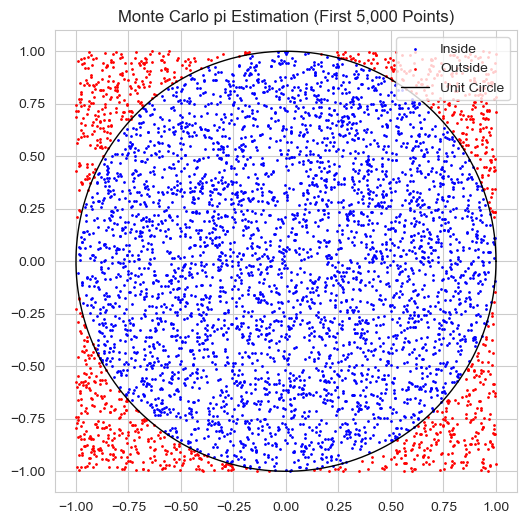

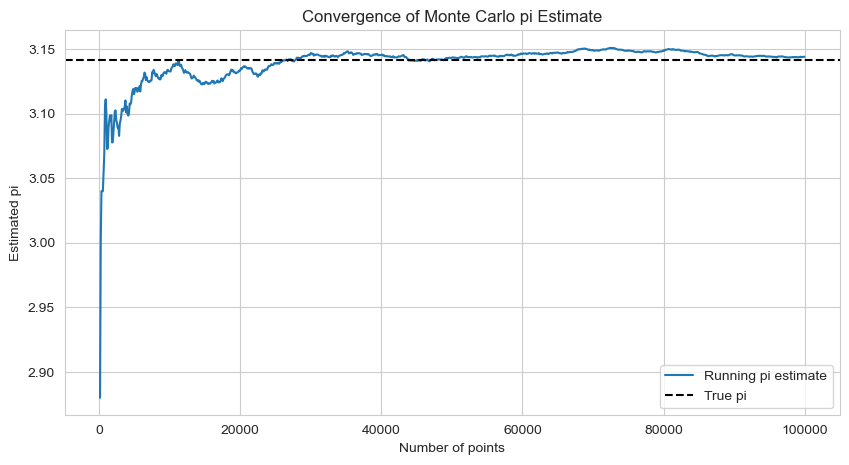

'\nThe estimate of pi usually stabilizes within ±0.01 of the true value when the number of points reaches around 50,000 to 60,000. \nBefore this, the estimate can fluctuate more due to randomness.\n'

In [2]:
N = 100_000

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

inside = x**2 + y**2 <= 1
points_inside = np.sum(inside)

pi_estimate = 4 * points_inside / N
print(f"Estimated pi: {pi_estimate}")
print(f"True pi: {np.pi}")

plt.figure(figsize=(6,6))
plt.scatter(x[:5000][inside[:5000]], y[:5000][inside[:5000]], color='blue', s=1, label='Inside')
plt.scatter(x[:5000][~inside[:5000]], y[:5000][~inside[:5000]], color='red', s=1, label='Outside')

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=1, label='Unit Circle')

plt.gca().set_aspect('equal', adjustable='box')
plt.title('Monte Carlo pi Estimation (First 5,000 Points)')
plt.legend()
plt.show()

running_estimates = []
for i in range(100, N+1, 100):
    running_estimates.append(4 * np.sum(inside[:i]) / i)

plt.figure(figsize=(10,5))
plt.plot(np.arange(100, N+1, 100), running_estimates, label='Running pi estimate')
plt.axhline(np.pi, color='black', linestyle='--', label='True pi')
plt.title('Convergence of Monte Carlo pi Estimate')
plt.xlabel('Number of points')
plt.ylabel('Estimated pi')
plt.legend()
plt.show()

"""
The estimate of pi usually stabilizes within ±0.01 of the true value when the number of points reaches around 50,000 to 60,000. 
Before this, the estimate can fluctuate more due to randomness.
"""

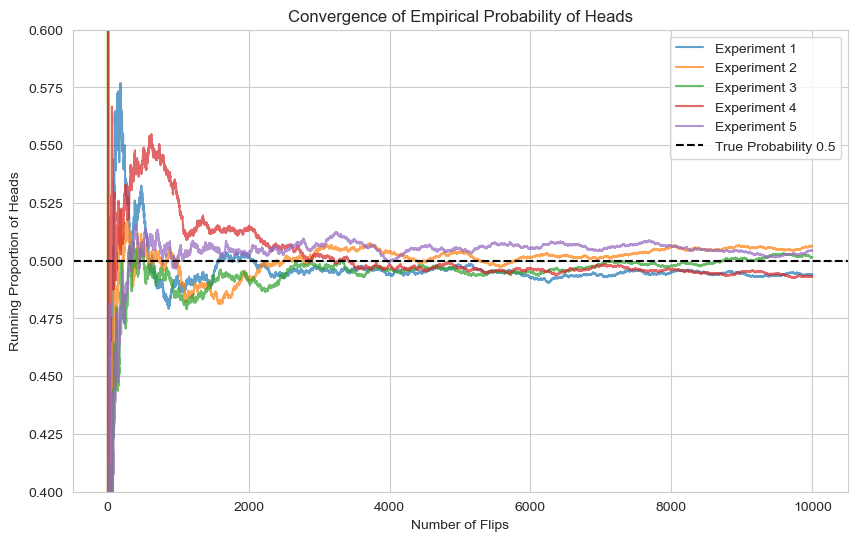

'\nTypically, the running proportion of heads stays within ±0.01 of 0.5 after around 2,000 to 3,000 flips\nEarly on, the proportion fluctuates more, but as the number of flips increases, it stabilizes near 0.5\n'

In [3]:
n_flips = 10_000
n_experiments = 5

plt.figure(figsize=(10,6))

for exp in range(n_experiments):
    flips = np.random.binomial(1, 0.5, size=n_flips)
    running_heads = np.cumsum(flips) / np.arange(1, n_flips+1)
    plt.plot(np.arange(1, n_flips+1), running_heads, label=f'Experiment {exp+1}', alpha=0.7)

plt.axhline(0.5, color='black', linestyle='--', label='True Probability 0.5')

plt.xlabel('Number of Flips')
plt.ylabel('Running Proportion of Heads')
plt.title('Convergence of Empirical Probability of Heads')
plt.ylim(0.4, 0.6)
plt.legend()
plt.show()

"""
Typically, the running proportion of heads stays within ±0.01 of 0.5 after around 2,000 to 3,000 flips
Early on, the proportion fluctuates more, but as the number of flips increases, it stabilizes near 0.5
"""

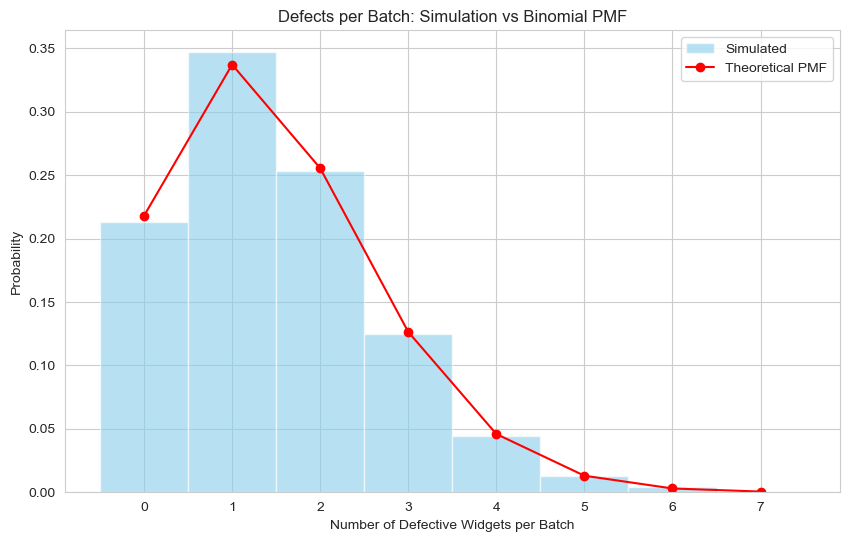

In [4]:
n_batches = 10_000
batch_size = 50
defect_rate = 0.03

defects_per_batch = np.random.binomial(n=batch_size, p=defect_rate, size=n_batches)
plt.figure(figsize=(10,6))
counts, bins, _ = plt.hist(defects_per_batch, bins=np.arange(0, max(defects_per_batch)+2)-0.5, density=True, alpha=0.6, color='skyblue', label='Simulated')

k = np.arange(0, max(defects_per_batch)+1)
pmf = binom.pmf(k, n=batch_size, p=defect_rate)
plt.plot(k, pmf, 'o-', color='red', label='Theoretical PMF')

plt.xlabel('Number of Defective Widgets per Batch')
plt.ylabel('Probability')
plt.title('Defects per Batch: Simulation vs Binomial PMF')
plt.legend()
plt.show()

p_0_defects_sim = np.mean(defects_per_batch == 0)
p_3_or_more_sim = np.mean(defects_per_batch >= 3)
expected_defects_sim = np.mean(defects_per_batch)

In [5]:
print("Simulation Estimates:")
print(f"P(0 defects) = {p_0_defects_sim:.4f}")
print(f"P(3 or more defects) = {p_3_or_more_sim:.4f}")
print(f"Expected number of defects = {expected_defects_sim:.2f}")

p_0_defects_theory = binom.pmf(0, n=batch_size, p=defect_rate)
p_3_or_more_theory = 1 - binom.cdf(2, n=batch_size, p=defect_rate)
expected_defects_theory = batch_size * defect_rate

print("\nTheoretical Values:")
print(f"P(0 defects) = {p_0_defects_theory:.4f}")
print(f"P(3 or more defects) = {p_3_or_more_theory:.4f}")
print(f"Expected number of defects = {expected_defects_theory:.2f}")

Simulation Estimates:
P(0 defects) = 0.2132
P(3 or more defects) = 0.1867
Expected number of defects = 1.50

Theoretical Values:
P(0 defects) = 0.2181
P(3 or more defects) = 0.1892
Expected number of defects = 1.50


In [6]:
p0_sim = np.mean(defects_per_batch == 0)
p3ormore_sim = np.mean(defects_per_batch >= 3)
expected_sim = np.mean(defects_per_batch)

p0_theory = binom.pmf(0, n=batch_size, p=defect_rate)
p3ormore_theory = 1 - binom.cdf(2, n=batch_size, p=defect_rate)
expected_theory = batch_size * defect_rate

print("Simulation vs Theoretical Binomial:")
print(f"P(0 defects): Sim = {p0_sim:.4f}, Theory = {p0_theory:.4f}")
print(f"P(3 or more defects): Sim = {p3ormore_sim:.4f}, Theory = {p3ormore_theory:.4f}")
print(f"Expected defects: Sim = {expected_sim:.2f}, Theory = {expected_theory:.2f}")

"""
The empirical estimates from 10,000 batches are very close to the theoretical values, usually within a few thousandths
With only 1,000 batches, the estimates would be more variable and less precise, so 10,000 batches gives a much more reliable approximation of the true probabilities
"""

Simulation vs Theoretical Binomial:
P(0 defects): Sim = 0.2132, Theory = 0.2181
P(3 or more defects): Sim = 0.1867, Theory = 0.1892
Expected defects: Sim = 1.50, Theory = 1.50


'\nThe empirical estimates from 10,000 batches are very close to the theoretical values, usually within a few thousandths\nWith only 1,000 batches, the estimates would be more variable and less precise, so 10,000 batches gives a much more reliable approximation of the true probabilities\n'